In [11]:
# Sam Brown
# sam_brown
# sam_brown@mines.edu
# Goal: Create data pipeline to retrieve seismic data for whillans events

import sys
sys.path.append("/Users/sambrown04/Documents/SURF/whillans-surf/notebooks/SURF")

import os

import obspy
from obspy import UTCDateTime
from obspy.clients.fdsn.mass_downloader import Restrictions, MassDownloader, GlobalDomain
import my_lib.funcs
from datetime import datetime

seismogram_path = './data/seismograms' # Set download path
xml_path = './data/stations' # Set XML path

In [3]:
# Manually set start time, number of days of data to download, and station info
start_time = obspy.UTCDateTime(2012, 1, 1)
days_to_download = 365
network = "IU" 
station = "QSPA" # South Pole seismic station
location = "00"
channel = "BH?" # ? is a wildcard for all channels starting with BH

# Set up to download from IRIS, using global domain because we're specifying
# specific stations
mdl = MassDownloader(providers=['IRIS'])
domain = GlobalDomain()

SEC_PER_DAY = 24 * 3600

# Download four days of data in one day chunks
for day in range(days_to_download):
    end_time = start_time + SEC_PER_DAY
    restrictions = Restrictions(
        starttime=start_time,
        endtime=end_time,
        chunklength_in_sec=SEC_PER_DAY, #1 day chunks
        network=network,
        station=station,
        location=location,
        channel=channel,
        reject_channels_with_gaps=False,
        minimum_length=0.0,
        minimum_interstation_distance_in_m=100.0 # Guard against same station having different names
        )
    mdl.download(domain, restrictions, mseed_storage=seismogram_path,
                stationxml_storage=xml_path,)
   
    start_time += SEC_PER_DAY # Update to next day

[2025-07-14 09:31:02,145] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for IRIS.
[2025-07-14 09:31:02,980] - obspy.clients.fdsn.mass_downloader - INFO: Successfully initialized 1 client(s): IRIS.
[2025-07-14 09:31:02,988] - obspy.clients.fdsn.mass_downloader - INFO: Total acquired or preexisting stations: 0
[2025-07-14 09:31:02,989] - obspy.clients.fdsn.mass_downloader - INFO: Client 'IRIS' - Requesting reliable availability.
[2025-07-14 09:31:03,153] - obspy.clients.fdsn.mass_downloader - INFO: Client 'IRIS' - Successfully requested availability (0.16 seconds)
[2025-07-14 09:31:03,154] - obspy.clients.fdsn.mass_downloader - INFO: Client 'IRIS' - Found 1 stations (3 channels).
[2025-07-14 09:31:03,156] - obspy.clients.fdsn.mass_downloader - INFO: Client 'IRIS' - Will attempt to download data from 1 stations.
[2025-07-14 09:31:03,157] - obspy.clients.fdsn.mass_downloader - INFO: Client 'IRIS' - Status for 3 time intervals/channels before downloading: EXISTS
[

In [5]:
# Load seismograms
inv =  obspy.read_inventory("./data/stations/*")
stream = obspy.Stream()

for trace_index in range(days_to_download):
    print(f"Working on {trace_index}")
    st_index = trace_index * 3  # Each day has 3 channels
    ed_index = trace_index * 3 + 3 
    for file in os.listdir(seismogram_path)[st_index:ed_index]:
        # Each mseed file may contain multiple traces that need to be combined
        temp_stream = obspy.read(f'{seismogram_path}/{file}')
        temp_stream.attach_response(inv)
        t1 = temp_stream[0]
    
        for trace in temp_stream[1:]:
            t1 = t1.__add__(trace, method=1,fill_value=0)
        stream.append(t1)

# Seperate into North, South, and Vertical components
stream.sort()
N = stream.select(channel='BH1')
E = stream.select(channel='BH2')
Z = stream.select(channel='BHZ')

# Make daily streams
day_streams = []
for day in range(len(N)):
    day_stream = obspy.Stream(traces=[N[day],E[day],Z[day]])
    day_streams.append(day_stream)


Working on 0
Working on 1
Working on 2
Working on 3
Working on 4
Working on 5
Working on 6
Working on 7
Working on 8
Working on 9
Working on 10
Working on 11
Working on 12
Working on 13
Working on 14
Working on 15
Working on 16
Working on 17
Working on 18
Working on 19
Working on 20
Working on 21
Working on 22
Working on 23
Working on 24
Working on 25
Working on 26
Working on 27
Working on 28
Working on 29
Working on 30
Working on 31
Working on 32
Working on 33
Working on 34
Working on 35
Working on 36
Working on 37
Working on 38
Working on 39
Working on 40
Working on 41
Working on 42
Working on 43
Working on 44
Working on 45
Working on 46
Working on 47
Working on 48
Working on 49
Working on 50
Working on 51
Working on 52
Working on 53
Working on 54
Working on 55
Working on 56
Working on 57
Working on 58
Working on 59
Working on 60
Working on 61
Working on 62
Working on 63
Working on 64
Working on 65
Working on 66
Working on 67
Working on 68
Working on 69
Working on 70
Working on 71
Wo

In [7]:
# Now we will pull all of the start times for the events in 2012 and generate streams for each event.
events_list = my_lib.funcs.load_evt("/Users/sambrown04/Documents/SURF/Events/2012_2012Events2stas")

In [13]:
start_times = []

for event in events_list:
    start_time = UTCDateTime(event['time'].iloc[0])
    end_time = UTCDateTime(event['time'].iloc[-1])
    start_times.append((start_time, end_time))

start_times.sort(key=lambda x: x[0])

In [15]:

for i, stream in enumerate(day_streams):
    filtered = stream.copy()
    filtered.filter("bandpass", freqmin=1/100, freqmax=1/30)
    day_streams[i] = filtered

In [46]:
# Want to loop through the start and end times and find 

for event in start_times:
    day_of_year = event[0].julday
    print(f"Event starts on day {day_of_year}")

Event starts on day 1
Event starts on day 1
Event starts on day 2
Event starts on day 2
Event starts on day 3
Event starts on day 3
Event starts on day 4
Event starts on day 5
Event starts on day 5
Event starts on day 6
Event starts on day 7
Event starts on day 8
Event starts on day 8
Event starts on day 9
Event starts on day 10
Event starts on day 11
Event starts on day 11
Event starts on day 12
Event starts on day 13
Event starts on day 13
Event starts on day 14
Event starts on day 15
Event starts on day 16
Event starts on day 16
Event starts on day 17
Event starts on day 18
Event starts on day 18
Event starts on day 19
Event starts on day 19
Event starts on day 20
Event starts on day 21
Event starts on day 21
Event starts on day 22
Event starts on day 23
Event starts on day 23
Event starts on day 24
Event starts on day 25
Event starts on day 25
Event starts on day 26
Event starts on day 27
Event starts on day 27
Event starts on day 28
Event starts on day 29
Event starts on day 30
Ev

In [23]:
day_stream[4].plot()

IndexError: list index out of range

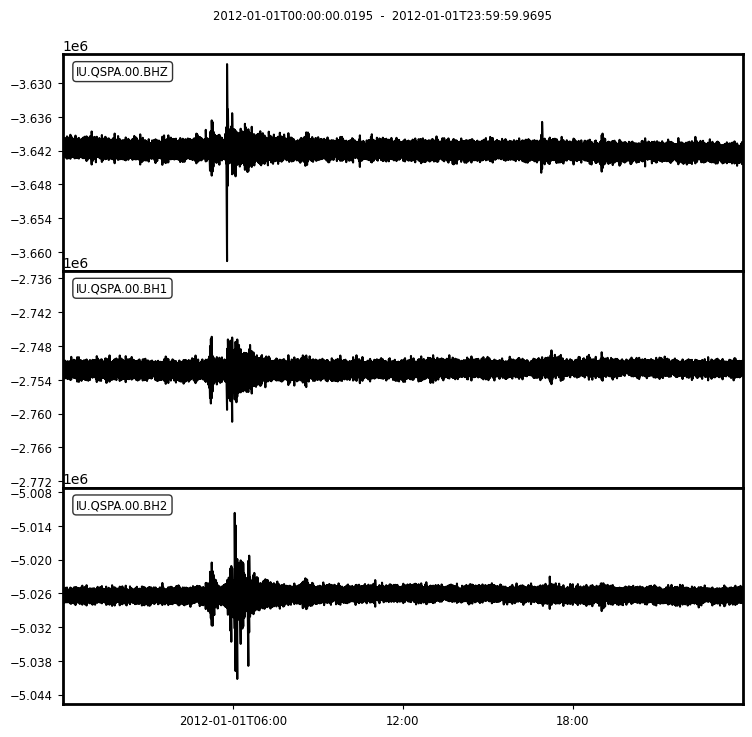

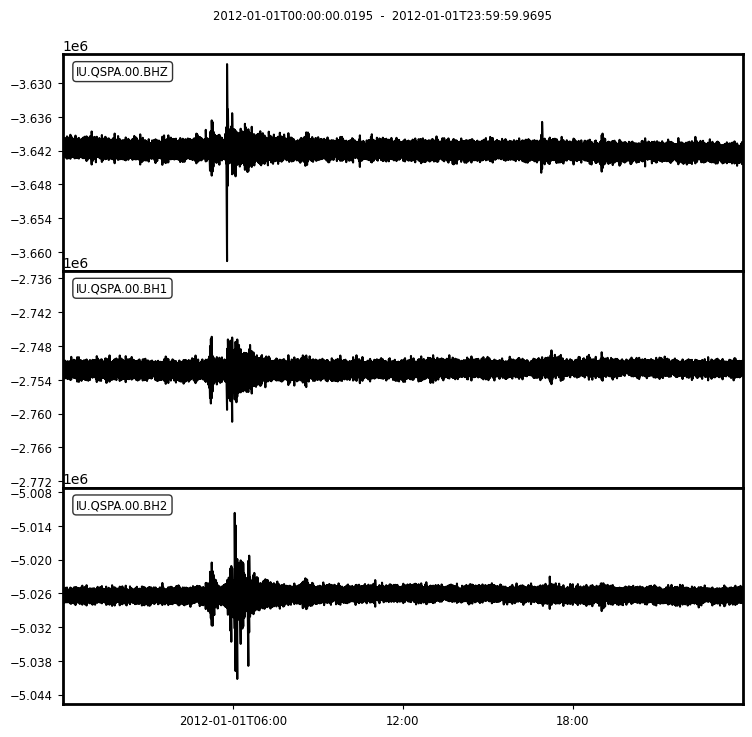

In [56]:
 # Filter and crop to Whillans event
# 2012-01-02 09:21:15, grabbed from Event Start Time list. Could also find programmatically
whillans_event_time = obspy.UTCDateTime("2012-01-02T09:21:15")
# Filter and trim
filtered_days = []
for day_stream in day_streams:
        filtered = day_stream.copy() # Filtering and trimming is done 'in place'
        #filt.remove_response() # Expensive!
        filtered.filter("bandpass", freqmin=1/100,freqmax=1/30) # Freqmin freqmax from Pratt et al., 2014
        filtered.trim(starttime=whillans_event_time - 3600, endtime=whillans_event_time +3600)
        filtered_days.append(filtered)